C:\Users\acezi\AppData\Local\Temp\ipykernel_22784\121308295.py:19: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv("auto-mpg.data", delim_whitespace=True, names=colnames, na_values='?')



<> In-Sample Performance <>
R2: 0.9257
Adj_R2: 0.9238
RMSE: 2.1586
MAE: 1.5433
ExplainedVar: 0.9257

<> Validation Performance (80/20) <>
R2: 0.9167
Adj_R2: 0.9073
RMSE: 2.1168
MAE: 1.5518
ExplainedVar: 0.9167


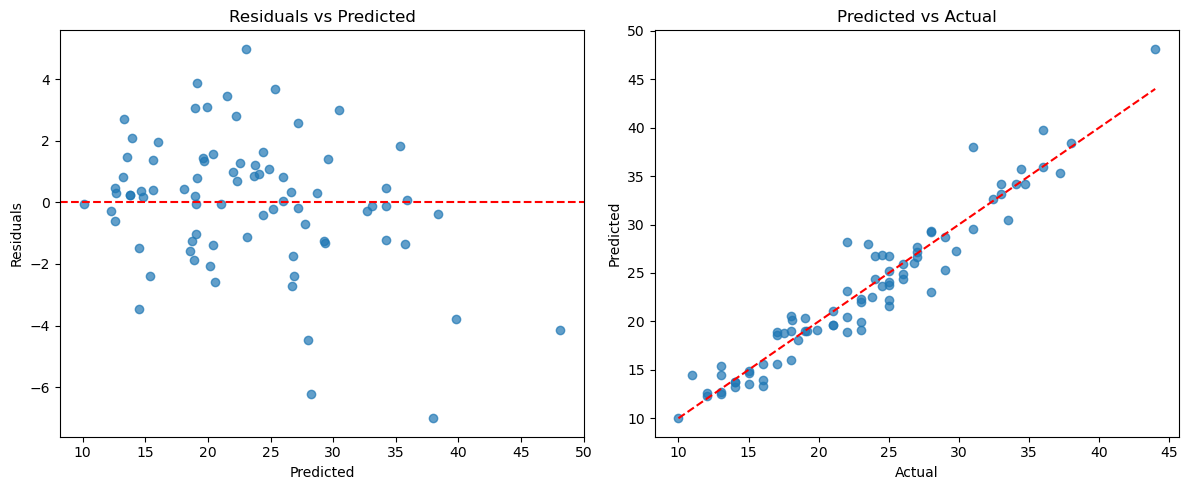


<> 5-Fold Cross-Validation Average Metrics <>


{'R2': 0.8712798237800599,
 'Adj_R2': 0.8566771218522454,
 'RMSE': 2.7904217,
 'MAE': 2.041292,
 'ExplainedVar': 0.8735165953636169}

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error, explained_variance_score
)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

RANDOM_STATE = 42
colnames = ["mpg","cylinders","displacement","horsepower","weight",
            "acceleration","model_year","origin","car_name"]

df = pd.read_csv("auto-mpg.data", delim_whitespace=True, names=colnames, na_values='?')
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce').fillna(df['horsepower'].median())
df = pd.get_dummies(df.drop(columns=['car_name']), columns=['origin'], drop_first=True)

X = df.drop(columns=['mpg']).values
y = df['mpg'].values.reshape(-1, 1)

scaler_X = StandardScaler()
scaler_y = StandardScaler()
X = scaler_X.fit_transform(X)
y = scaler_y.fit_transform(y)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train, dtype=torch.float32).to(device)
X_val = torch.tensor(X_val, dtype=torch.float32).to(device)
y_val = torch.tensor(y_val, dtype=torch.float32).to(device)

class MPGModel(nn.Module):
    def __init__(self, input_dim, hidden1=64, hidden2=32, activation='relu'):
        super(MPGModel, self).__init__()
        act_fn = nn.ReLU() if activation == 'relu' else nn.Tanh()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            act_fn,
            nn.Linear(hidden1, hidden2),
            act_fn,
            nn.Linear(hidden2, 1)
        )

    def forward(self, x):
        return self.net(x)

def train_model(model, X_train, y_train, X_val, y_val, epochs=200, lr=0.001):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        y_pred = model(X_train)
        loss = criterion(y_pred, y_train)
        loss.backward()
        optimizer.step()

        if (epoch + 1) % 50 == 0:
            model.eval()
            with torch.no_grad():
                val_pred = model(X_val)
                val_loss = criterion(val_pred, y_val)
    return model

def regression_metrics(y_true, y_pred, n_features):
    n = len(y_true)
    r2 = r2_score(y_true, y_pred)
    adj_r2 = 1 - (1 - r2) * ((n - 1) / (n - n_features - 1))
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    evs = explained_variance_score(y_true, y_pred)
    return {
        "R2": r2,
        "Adj_R2": adj_r2,
        "RMSE": rmse,
        "MAE": mae,
        "ExplainedVar": evs
    }

input_dim = X_train.shape[1]
model = MPGModel(input_dim, hidden1=64, hidden2=32, activation='relu').to(device)
trained_model = train_model(model, X_train, y_train, X_val, y_val, epochs=300, lr=0.001)

model.eval()
with torch.no_grad():
    y_train_pred = model(X_train).cpu().numpy()
    y_val_pred = model(X_val).cpu().numpy()

y_train_true = scaler_y.inverse_transform(y_train.cpu().numpy())
y_val_true = scaler_y.inverse_transform(y_val.cpu().numpy())
y_train_pred = scaler_y.inverse_transform(y_train_pred)
y_val_pred = scaler_y.inverse_transform(y_val_pred)

print("\n<> In-Sample Performance <>")
train_metrics = regression_metrics(y_train_true, y_train_pred, X_train.shape[1])
for k, v in train_metrics.items():
    print(f"{k}: {v:.4f}")

print("\n<> Validation Performance (80/20) <>")
val_metrics = regression_metrics(y_val_true, y_val_pred, X_val.shape[1])
for k, v in val_metrics.items():
    print(f"{k}: {v:.4f}")

residuals = y_val_true.flatten() - y_val_pred.flatten()

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(y_val_pred, residuals, alpha=0.7)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")

plt.subplot(1,2,2)
plt.scatter(y_val_true, y_val_pred, alpha=0.7)
plt.plot([y_val_true.min(), y_val_true.max()],
         [y_val_true.min(), y_val_true.max()],
         'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs Actual")
plt.tight_layout()
plt.show()

def cross_validate(X, y, hidden1=64, hidden2=32, activation='relu', folds=5):
    kf = KFold(n_splits=folds, shuffle=True, random_state=42)

    all_metrics = {"R2": [], "Adj_R2": [], "RMSE": [], "MAE": [], "ExplainedVar": []}

    for train_idx, test_idx in kf.split(X):
        X_train_fold = torch.tensor(X[train_idx], dtype=torch.float32).to(device)
        X_test_fold  = torch.tensor(X[test_idx], dtype=torch.float32).to(device)
        y_train_fold = torch.tensor(y[train_idx], dtype=torch.float32).to(device)
        y_test_fold  = torch.tensor(y[test_idx], dtype=torch.float32).to(device)

        model = MPGModel(X.shape[1], hidden1, hidden2, activation).to(device)
        train_model(model, X_train_fold, y_train_fold, X_test_fold, y_test_fold, epochs=150, lr=0.001)

        model.eval()
        with torch.no_grad():
            y_pred = model(X_test_fold).cpu().numpy()

        y_true = scaler_y.inverse_transform(y_test_fold.cpu().numpy())
        y_pred = scaler_y.inverse_transform(y_pred)

        metrics = regression_metrics(y_true, y_pred, X.shape[1])
        for k in all_metrics.keys():
            all_metrics[k].append(metrics[k])

    avg_metrics = {k: np.mean(v) for k, v in all_metrics.items()}
    print(f"\n<> {folds}-Fold Cross-Validation Average Metrics <>")
    return avg_metrics

cross_validate(X, y)